In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


from msi_res import msi_res as res

from msi_res.msi_res import calculate_esf 
from msi_res.msi_res import calculate_mtf 

Define a simple function that loads data. This can be improved in a lot of ways.


In [2]:
def load_dcube(path, mzs, im_y, im_x):
    
    dcube = np.zeros((mzs, im_y, im_x))
    
    for i in range(mzs):
        dcube[i] = np.array(pd.read_csv(path + '\{}'.format(i+1)))
    return dcube

In [3]:
#load the data

dc60 = load_dcube(r'C:\Users\Martin\Desktop\work\gold_data\gold60um_roi4', 2000, 39, 40)

In [4]:
#find the top 30 most intense images

mean_intens = np.zeros(dc60.shape[0])

for i in range(mean_intens.shape[0]):
    mean_intens[i] = np.mean(dc60[i][:,20:])

In [5]:
(-mean_intens).argsort()[:30]

array([  43,  644, 1350,  418,  521, 1731,  732,  395, 1353,  725,  500,
       1903,  647, 1219,  258,  411,   77, 1235,  981,  567, 1144,  269,
       1400, 1102,  573,  593,   24,  262, 1748, 1732], dtype=int64)

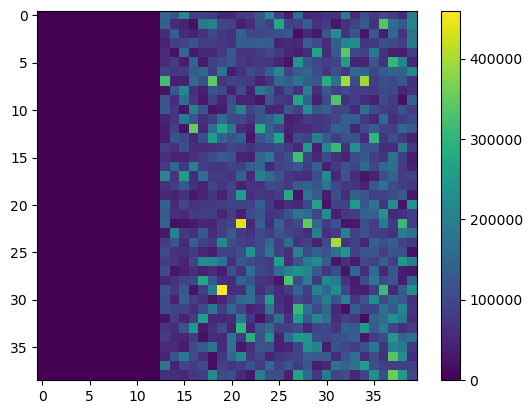

In [6]:
#display gold image 
plt.imshow(dc60[43])
plt.colorbar()

You can check what the calculate_esf and calculate_mtf functions by adding a question mark

In [12]:
calculate_esf?

In [13]:
calculate_mtf?

Estimate the edge spread function and the MTF

(0.22282966792241526,
 1.7091590105735806,
 112247.19230769231,
 0.011659843349510278)

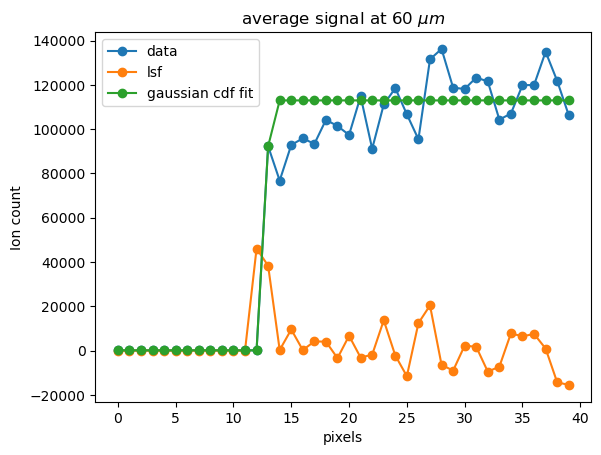

In [8]:
calculate_esf(dc60[43], pixel_size=60, disp=1, simplified=True)

Blur is 0.22. Reduced chi squared indicates overfitting due to noise. The 86-14% would predict a 0.44 pixel resolution
SNR is 1.7 
Average surface intensity is  112247

(0.3521, 70.42886516635062, 0.054814759876796244)

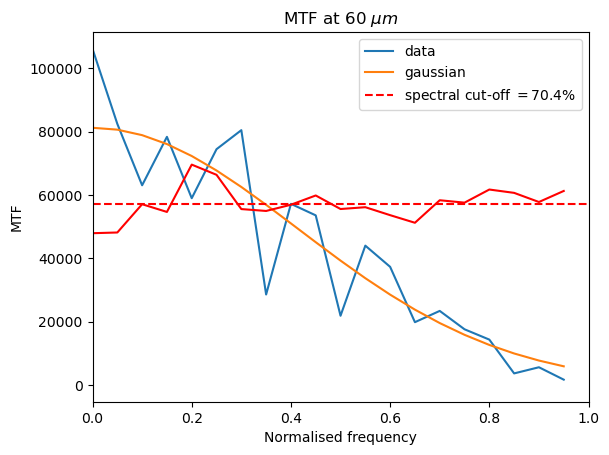

In [9]:
calculate_mtf(dc60[43], 60, 1, med_filt=True, fit_to_fourier=True)


Resolution frequency is 0.3521

You can find the resolution in pixels with 
$2/f_{c}$

or in microns with 

$\dfrac{2p}{f_{c}}$ 

where $p$ is the pixel size in microns

In [14]:
2*60/0.35

342.8571428571429